# **Part of Speech (POS) Tagging using Hidden Markov Models (HMM)**

This project implements a custom **Hidden Markov Model (HMM)** from scratch to predict Part-of-Speech (POS) tags for Turkish language text. 

Using the **Viterbi Algorithm** (a dynamic programming approach), the model calculates optimal tag sequences by combining transition and emission probabilities trained on the Google Turkish Treebanks dataset (web and wiki corpora combined).

## **Pipeline Overview**
1. **Data Preprocessing**: Loading `.conllu` files, splitting into 80% train and 20% test sets.
2. **Probability Estimation**: Calculating Transition and Emission matrices using Maximum Likelihood Estimation (MLE) with Laplace/Add-k smoothing.
3. **Viterbi Decoding**: Implementing the dynamic programming algorithm to find the most likely sequence of hidden states (POS tags) for any given sentence.
4. **Evaluation**: Testing on full 14-tag and reduced 5-tag sets, evaluating overall accuracy and analyzing errors.

In [57]:
def read_conll(file_path):
    sentences = []
    sentence = []

    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()

            # Skip metadata lines starting with "#"
            if line.startswith("#"):
                continue

            # Sentence boundary (blank line)
            if not line:
                if sentence:
                    sentences.append(sentence)
                    sentence = []
            else:
                # Split the line into columns and extract word and POS tag
                columns = line.split('\t')
                if len(columns) > 3:  # Check to ensure the line has expected columns
                    word = columns[2]
                    if word == '_':
                      continue

                    pos_tag = columns[3]
                    sentence.append((word, pos_tag))

        # Add the last sentence if the file doesn't end with a blank line
        if sentence:
            sentences.append(sentence)

    return sentences

# Usage
web_file_path = "web.conllu"
wiki_file_path = "wiki.conllu"

web_sentences = read_conll(web_file_path)
wiki_sentences = read_conll(wiki_file_path)

sentences = web_sentences + wiki_sentences

In [58]:
len(sentences)

4851

## 1. Preprocessing function

In [ ]:
def prepare_data(sentences, tag_list):

    """
    Filters sentences to keep only words with tags in tag_list. 
    Adds START and END tags to each sentence.
    """
    prepared_sentences = []

    for sentence in sentences: # Filter words based on tag_list
        filtered_sentence = []
        for word, pos_tag in sentence:
            if pos_tag in tag_list:
                filtered_sentence.append((word, pos_tag))

        # For only add sentence if it has any words after filtering
        if filtered_sentence:
            filtered_sentence.insert(0, ('<START>', '<START>'))  # Add START and END markers
            filtered_sentence.append(('<END>', '<END>'))
            prepared_sentences.append(filtered_sentence)

    return prepared_sentences

## 2. Train test split

In [ ]:
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42
train_sentences, test_sentences = train_test_split(
    sentences,
    test_size=0.2,      # 0.8 / 0.2
    random_state=RANDOM_STATE
)

print(f"Training sentences --> {len(train_sentences)}")
print(f"Test sentences --> {len(test_sentences)}")
print(f"Total sentences --> {len(sentences)}")

Training sentences --> 3880
Test sentences --> 971
Total sentences --> 4851


## 3. Model Training



In [ ]:
def create_HMM(train_sentences):
    '''
    type train_sentences: list of tuples
    param train_sentences: The list of tuples (word, POS tag) for the training data sentences
    rtype: dict
    return: the transitions count dictionary between tags
    rtype: dict
    return: the emissions count dictionary for tags and words
    rtype: dict
    return: the tag count dictionary for the POS tags
    rtype: set
    return: the vocabulary of the corpus
    '''

    from collections import defaultdict

    # Initializing dictionaries
    transitions = defaultdict(lambda: defaultdict(int))  # transitions[tag1][tag2] = count
    emissions = defaultdict(lambda: defaultdict(int))    # emissions[tag][word] = count
    tag_counts = defaultdict(int)                        # tag_counts[tag] = count
    word_count = defaultdict(int)                        # word_count[word] = count
    vocab = set()

    # Process each sentence
    for sentence in train_sentences:
        for i in range(len(sentence)):
            word, tag = sentence[i]

            if word not in ['<START>', '<END>']:     #adding word to vocabulary (except START and END)
                vocab.add(word)
                word_count[word] += 1


            emissions[tag][word] += 1  #count emissions: tag -> word
            tag_counts[tag] += 1       #count tags

            # count transitions: current_tag -> next_tag
            if i < len(sentence) - 1:  # if not the last word
                next_tag = sentence[i + 1][1]
                transitions[tag][next_tag] += 1

    # Convert defaultdicts to regular dicts for cleaner output
    transitions = {tag: dict(next_tags) for tag, next_tags in transitions.items()}
    emissions = {tag: dict(words) for tag, words in emissions.items()}
    tag_counts = dict(tag_counts)
    word_count = dict(word_count)

    return transitions, emissions, tag_counts, vocab, word_count

In [62]:
transitions, emissions, tag_counts, vocab, word_count = create_HMM(train_sentences)

## 4. POS tag prediction for test data

Write Viterbi algorithm to predict the POS tags of the test data.

In [ ]:
import numpy as np
import math
def viterbi(test_sentence, transitions, emissions, tag_counts, word_count):
    '''
    type test_sentence: list of strings
    param test_sentence: list of words in a sentence
    type transitions: dict
    param: the transitions count dictionary between tags
    type emissions: dict
    param: the emissions count dictionary for tags and words
    type tag_counts: dict
    param: the tag count dictionary for the POS tags
    type word_count: int
    param: the word count of the training corpus
    rtype: list
    return: the list of predicted tags for the test sentence

    '''
    #viterbi matrix for the test sentence. The matrix has +2 in each side since we add
    #START and END tags for probability calculation.
    v_matrix = np.empty(shape=(len(tag_counts)+2,len(test_sentence)+2))
    v_matrix.fill(-1)
    v_matrix[0][0] = 0

    #fill up the viterbi matrix for each cell, starting with the first word.
    # for every word, check each tag's probability of appearing here.
    ## iterate over the tags:
    ## calculate the best transition probability for the current tag from a previous tag (again iteration of all possible tags)
    ## calculate the emission probability of word coming up from the current tag
    ## sum them up to get to the best probability of P(tag|word).
    ## keep the best path coming to that cell
    #after filling up the viterbi matrix, follow the best path back to predict the tags from the final cell.
    # in the end we are looking at len(tags)xlen(tags) possibilities for each word



    all_tags = [tag for tag in tag_counts.keys() if tag not in ['<START>', '<END>']]  #all tags (excluding START and END for now)
    test_sentence = ['<START>'] + test_sentence + ['<END>']  #add START tag at the beginning
    tracker = {}    #for tracking best paths
    alpha = 0.001   #smoothing parameter for unseen transitions/emissions

    # Initialize: START -> first word
    for tag_idx, tag in enumerate(all_tags):
        #transition probability: START -> tag
        trans_prob = (transitions.get('<START>', {}).get(tag, 0) + alpha) / \
                     (tag_counts.get('<START>', 0) + alpha * len(all_tags))

        #emission probability: tag -> first_word
        word = test_sentence[1]  # first actual word (index 0 is START)
        emit_prob = (emissions.get(tag, {}).get(word, 0) + alpha) / \
                    (tag_counts.get(tag, 0) + alpha * len(word_count))

        # log probability (to avoid underflow)
        v_matrix[tag_idx + 1][1] = math.log(trans_prob) + math.log(emit_prob)
        tracker[(tag_idx + 1, 1)] = 0

    #forward pass: for each word in the sentence
    for word_idx in range(2, len(test_sentence) - 1):  # skip START and END
        word = test_sentence[word_idx]

        for curr_tag_idx, curr_tag in enumerate(all_tags):
            max_prob = float('-inf')
            best_prev_tag_idx = -1

            #chekcing all possible previous tags
            for prev_tag_idx, prev_tag in enumerate(all_tags):
                prev_viterbi = v_matrix[prev_tag_idx + 1][word_idx - 1]  #previous viterbi probability

                if prev_viterbi == -1:  #skip if not computed
                    continue

                #transition probability: prev_tag -> curr_tag
                trans_prob = (transitions.get(prev_tag, {}).get(curr_tag, 0) + alpha) / \
                            (tag_counts.get(prev_tag, 0) + alpha * len(all_tags))

                #emission probability: curr_tag -> word
                emit_prob = (emissions.get(curr_tag, {}).get(word, 0) + alpha) / \
                           (tag_counts.get(curr_tag, 0) + alpha * len(word_count))

                #total probability
                prob = prev_viterbi + math.log(trans_prob) + math.log(emit_prob)

                if prob > max_prob:
                    max_prob = prob
                    best_prev_tag_idx = prev_tag_idx + 1

            v_matrix[curr_tag_idx + 1][word_idx] = max_prob
            tracker[(curr_tag_idx + 1, word_idx)] = best_prev_tag_idx

    #termination: transition to END tag
    last_word_idx = len(test_sentence) - 2
    max_prob = float('-inf')
    best_last_tag_idx = -1

    for tag_idx, tag in enumerate(all_tags):
        prev_viterbi = v_matrix[tag_idx + 1][last_word_idx]

        if prev_viterbi == -1:
            continue

        # transition to END
        trans_prob = (transitions.get(tag, {}).get('<END>', 0) + alpha) / \
                    (tag_counts.get(tag, 0) + alpha * len(all_tags))

        prob = prev_viterbi + math.log(trans_prob)

        if prob > max_prob:
            max_prob = prob
            best_last_tag_idx = tag_idx + 1

    #backtrack to find best path
    predicted_tags = []
    current_idx = best_last_tag_idx

    for word_idx in range(last_word_idx, 0, -1):
        predicted_tags.insert(0, all_tags[current_idx - 1])
        current_idx = tracker.get((current_idx, word_idx), 0)

    return predicted_tags

## 5. Evaluating HMM



## 5.1

The first HMM is trained using all 14 POS tags from the dataset.
This model provides detailed grammatical analysis but faces higher classification complexity.

In [64]:
# MODEL A: All 14 POS tags
print("MODEL A: Training with ALL POS tags -->")
print("")

# get all unique tags from the dataset
all_tags = list(set([tag for sentence in sentences for word, tag in sentence]))
print(f"All tags ({len(all_tags)}): {sorted(all_tags)}")

#prepare data with all tags
train_sentences_a = prepare_data(train_sentences, all_tags)
test_sentences_a = prepare_data(test_sentences, all_tags)

#Train Model A
transitions_a, emissions_a, tag_counts_a, vocab_a, word_count_a = create_HMM(train_sentences_a)

print(f"Number of tags: {len(tag_counts_a)}")
print(f"Vocabulary size: {len(vocab_a)}")

MODEL A: Training with ALL POS tags -->

All tags (14): ['ADJ', 'ADP', 'ADV', 'AFFIX', 'CONJ', 'DET', 'NOUN', 'NUM', 'ONOM', 'PRON', 'PRT', 'PUNCT', 'VERB', 'X']
Number of tags: 16
Vocabulary size: 8064


## 5.2

Evaluating Model A performance on test set using Viterbi algorithm.
Metrics: Accuracy, F1-Score, and Confusion Matrix visualization.

MODEL A: EVALUATION

Accuracy: 0.8340
F1 Score: 0.8529


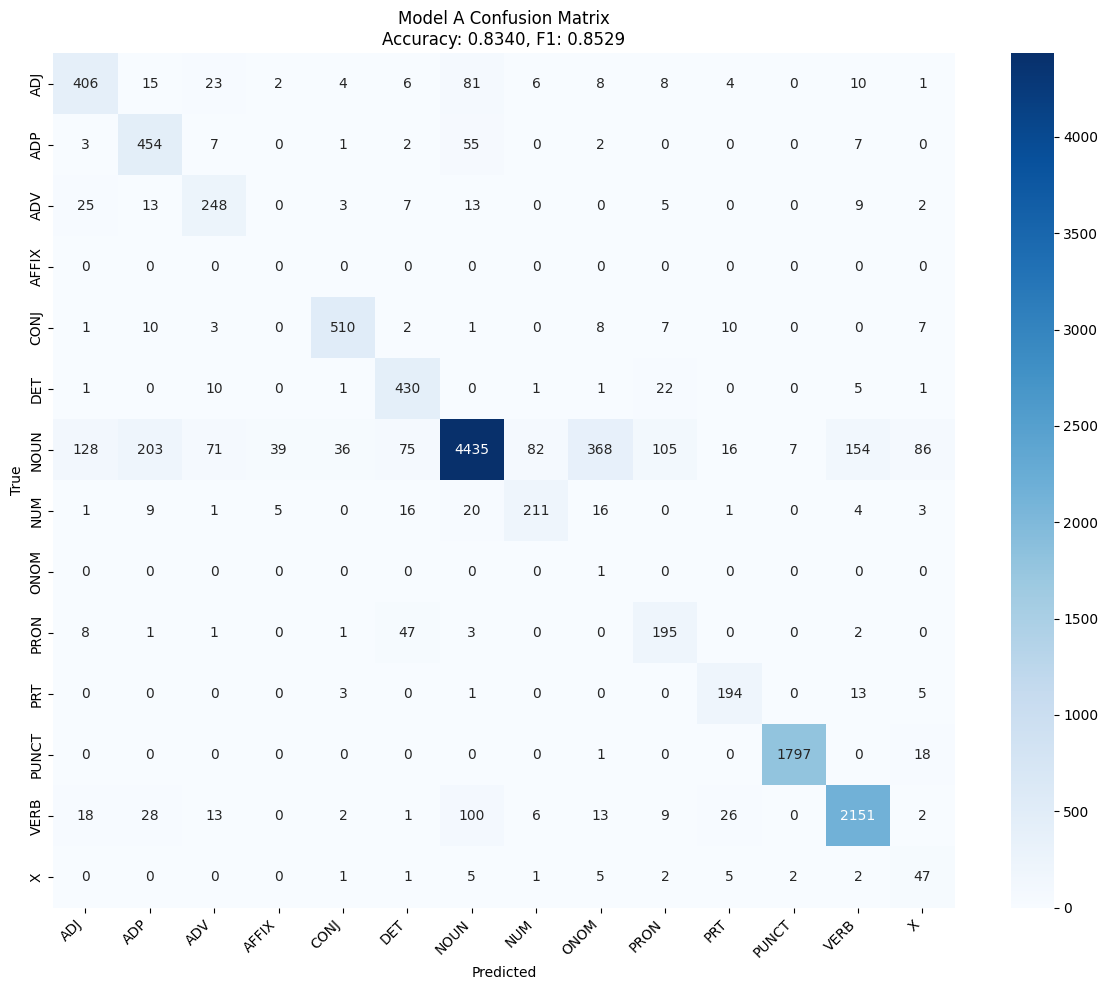


Classification Report:
              precision    recall  f1-score   support

         ADJ       0.69      0.71      0.70       574
         ADP       0.62      0.85      0.72       531
         ADV       0.66      0.76      0.71       325
       AFFIX       0.00      0.00      0.00         0
        CONJ       0.91      0.91      0.91       559
         DET       0.73      0.91      0.81       472
        NOUN       0.94      0.76      0.84      5805
         NUM       0.69      0.74      0.71       287
        ONOM       0.00      1.00      0.00         1
        PRON       0.55      0.76      0.64       258
         PRT       0.76      0.90      0.82       216
       PUNCT       1.00      0.99      0.99      1816
        VERB       0.91      0.91      0.91      2369
           X       0.27      0.66      0.39        71

    accuracy                           0.83     13284
   macro avg       0.62      0.78      0.65     13284
weighted avg       0.88      0.83      0.85     13284



In [65]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("MODEL A: EVALUATION")
print("")

#preparing test data
test_words_a = []
true_labels_a = []

for sentence in test_sentences_a:
    words = [word for word, tag in sentence if tag not in ['<START>', '<END>']]
    tags = [tag for word, tag in sentence if tag not in ['<START>', '<END>']]
    test_words_a.append(words)
    true_labels_a.extend(tags)

#predict
predicted_labels_a = []
for sentence_words in test_words_a:
    predicted_tags = viterbi(sentence_words, transitions_a, emissions_a, tag_counts_a, word_count_a)
    predicted_labels_a.extend(predicted_tags)

#metrics that I used
accuracy_a = accuracy_score(true_labels_a, predicted_labels_a)
f1_a = f1_score(true_labels_a, predicted_labels_a, average='weighted')

print(f"Accuracy: {accuracy_a:.4f}")
print(f"F1 Score: {f1_a:.4f}")

# Confusion Matrix for visualizing
conf_matrix_a = confusion_matrix(true_labels_a, predicted_labels_a)
unique_labels_a = sorted(list(set(true_labels_a + predicted_labels_a)))

plt.figure(figsize=(12, 10))
sns.heatmap(conf_matrix_a, annot=True, fmt='d', cmap='Blues',
            xticklabels=unique_labels_a, yticklabels=unique_labels_a)
plt.title(f'Model A Confusion Matrix\nAccuracy: {accuracy_a:.4f}, F1: {f1_a:.4f}')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(true_labels_a, predicted_labels_a))

## 5.3

The second HMM is trained using ONLY 5 major POS tags --> ADJ, ADV, NOUN, VERB, PUNCT.
This simplified model focuses on core grammatical categories with reduced complexity.

In [66]:
#MODEL B: Only 5 selected POS tags
print("MODEL B: Training with 5 selected POS tags -->")
print("")

selected_tags = ['ADJ', 'ADV', 'NOUN', 'VERB', 'PUNCT'] #selected tags only
print(f"Selected tags ({len(selected_tags)}): {selected_tags}")

#prepare data with selected tags
train_sentences_b = prepare_data(train_sentences, selected_tags)
test_sentences_b = prepare_data(test_sentences, selected_tags)

transitions_b, emissions_b, tag_counts_b, vocab_b, word_count_b = create_HMM(train_sentences_b)  #train Model B

print(f"Number of tags: {len(tag_counts_b)}")
print(f"Vocabulary size: {len(vocab_b)}")

MODEL B: Training with 5 selected POS tags -->

Selected tags (5): ['ADJ', 'ADV', 'NOUN', 'VERB', 'PUNCT']
Number of tags: 7
Vocabulary size: 7554


## 5.4

Evaluating Model B performance on filtered test set.
Expected to show different accuracy-complexity tradeoffs compared to Model A.

MODEL B: EVALUATION

Accuracy: 0.8646
F1 Score: 0.8747


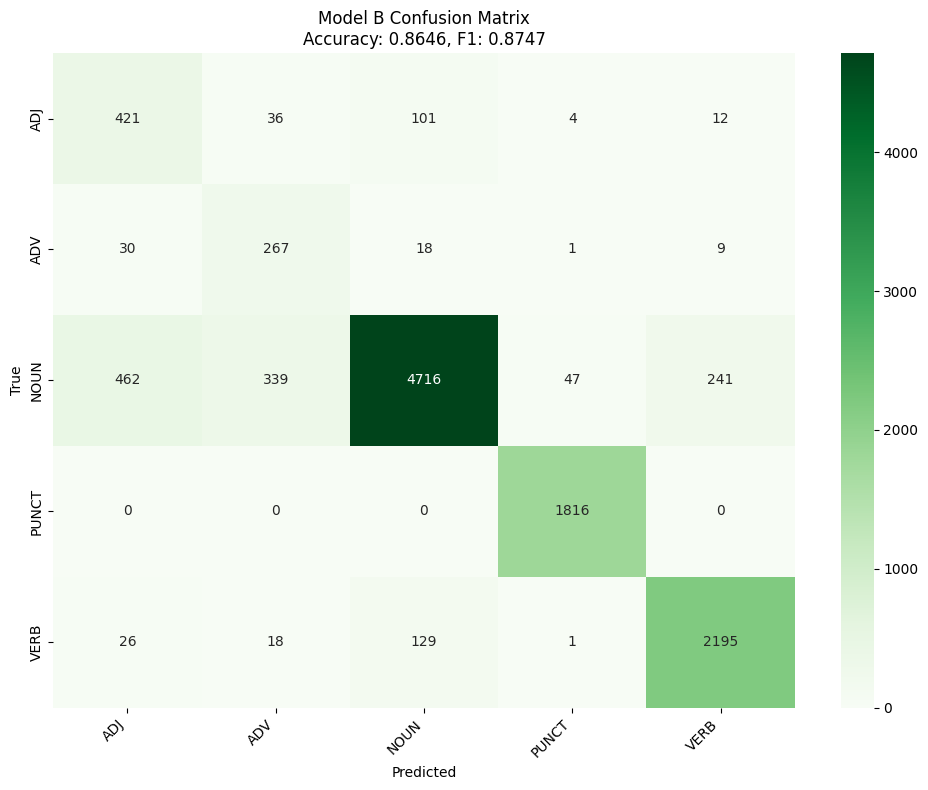


Classification Report:
              precision    recall  f1-score   support

         ADJ       0.45      0.73      0.56       574
         ADV       0.40      0.82      0.54       325
        NOUN       0.95      0.81      0.88      5805
       PUNCT       0.97      1.00      0.99      1816
        VERB       0.89      0.93      0.91      2369

    accuracy                           0.86     10889
   macro avg       0.73      0.86      0.77     10889
weighted avg       0.90      0.86      0.87     10889



In [67]:
print("MODEL B: EVALUATION")
print("")

#preparing test data
test_words_b = []
true_labels_b = []

for sentence in test_sentences_b:
    words = [word for word, tag in sentence if tag not in ['<START>', '<END>']]
    tags = [tag for word, tag in sentence if tag not in ['<START>', '<END>']]
    test_words_b.append(words)
    true_labels_b.extend(tags)

#predict
predicted_labels_b = []
for sentence_words in test_words_b:
    predicted_tags = viterbi(sentence_words, transitions_b, emissions_b, tag_counts_b, word_count_b)
    predicted_labels_b.extend(predicted_tags)

#metrics
accuracy_b = accuracy_score(true_labels_b, predicted_labels_b)
f1_b = f1_score(true_labels_b, predicted_labels_b, average='weighted')

print(f"Accuracy: {accuracy_b:.4f}")
print(f"F1 Score: {f1_b:.4f}")

#confusion matrix for visiualizng
conf_matrix_b = confusion_matrix(true_labels_b, predicted_labels_b)
unique_labels_b = sorted(list(set(true_labels_b + predicted_labels_b)))

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix_b, annot=True, fmt='d', cmap='Greens',
            xticklabels=unique_labels_b, yticklabels=unique_labels_b)
plt.title(f'Model B Confusion Matrix\nAccuracy: {accuracy_b:.4f}, F1: {f1_b:.4f}')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(true_labels_b, predicted_labels_b))

## 5.5 Comparison

I compared Model A (14 tags) vs Model B (5 tags) in terms of:
- Accuracy and F1-Score metrics
- Computational complexity
- Tag distribution and confusion patterns

MODEL COMPARISON: A vs B

                   Model  Accuracy  F1-Score  Number of Tags
0  Model A (All 14 tags)  0.834011  0.852914              14
1  Model B (5 tags only)  0.864634  0.874716               5


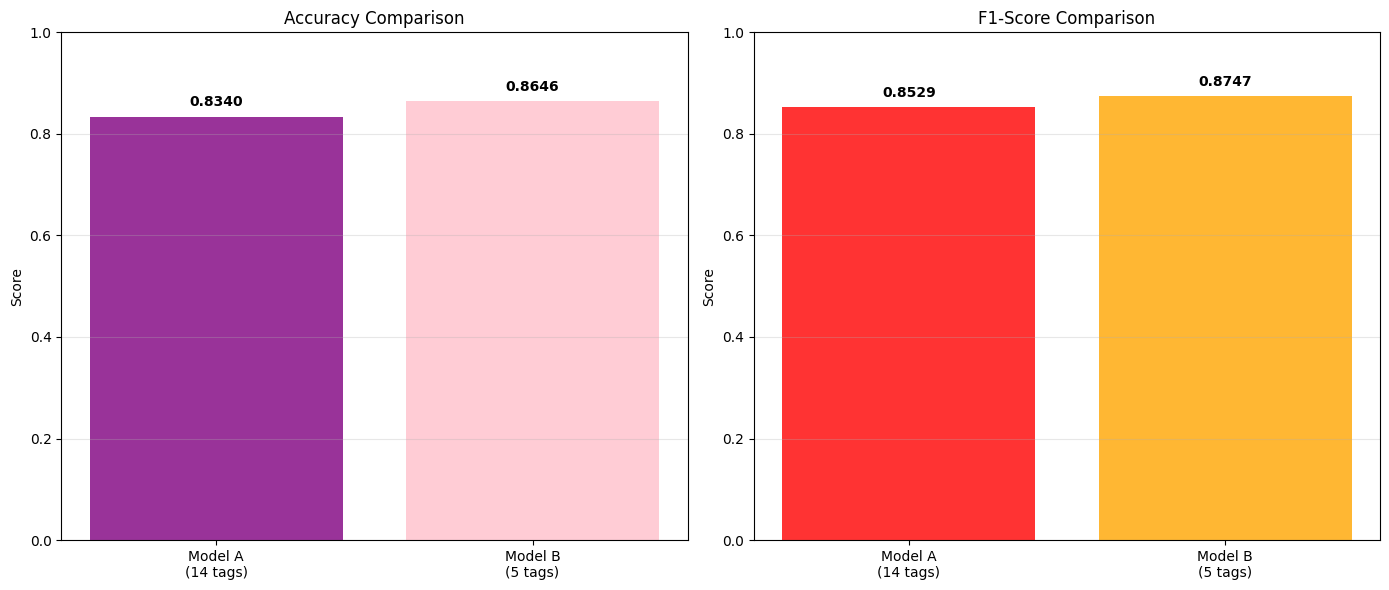

In [68]:
print("MODEL COMPARISON: A vs B")
print("")

import pandas as pd

comparison = pd.DataFrame({
    'Model': ['Model A (All 14 tags)', 'Model B (5 tags only)'],
    'Accuracy': [accuracy_a, accuracy_b],
    'F1-Score': [f1_a, f1_b],
    'Number of Tags': [len(unique_labels_a), len(unique_labels_b)]
})

print(comparison)

#compare visualization
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

models = ['Model A\n(14 tags)', 'Model B\n(5 tags)']
accuracies = [accuracy_a, accuracy_b]
f1_scores = [f1_a, f1_b]

ax[0].bar(models, accuracies, color=['purple', 'pink'], alpha=0.8)
ax[0].set_ylim(0, 1.0)
ax[0].set_ylabel('Score')
ax[0].set_title('Accuracy Comparison')
ax[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(accuracies):
    ax[0].text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')

ax[1].bar(models, f1_scores, color=['red', 'orange'], alpha=0.8)
ax[1].set_ylim(0, 1.0)
ax[1].set_ylabel('Score')
ax[1].set_title('F1-Score Comparison')
ax[1].grid(axis='y', alpha=0.3)
for i, v in enumerate(f1_scores):
    ax[1].text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# 6. POS Tagging using Hidden Markov Models Report


## 1. Data Preparation Methodology
The dataset is constructed from the **Google Turkish Treebank** (specifically merging `web.conll` and `wiki.conll` files), yielding a total of **4,851 sentences**. 

* **Data Split**: For robust evaluation and reproducibility, the dataset is split into an **80/20** ratio using a fixed seed (`random_state=42`):
  * **Training Set**: 3,880 sentences
  * **Test Set**: 971 sentences
* **Preprocessing**: The pipeline utilizes a custom `prepare_data()` function to filter sentences based on target tags and appends `<START>` and `<END>` boundary markers to each sequence to properly model state transitions.
* **Experimental Setups**: Two distinct models are trained and compared:
  * **Model A**: Full granular setup containing all **14 standard POS tags**.
  * **Model B**: Reduced setup containing **5 core POS tags** (`ADJ`, `ADV`, `NOUN`, `VERB`, `PUNCT`).

---

## 2. Mathematical Modeling & Probability Estimation
The tagger relies on **Maximum Likelihood Estimation (MLE)** to compute probability matrices from the training corpus:

### Transition Probabilities
Calculates the likelihood of moving from one grammatical state to another:
$$P(\text{tag}_i \mid \text{tag}_{i-1}) = \frac{\text{Count}(\text{tag}_{i-1}, \text{tag}_i)}{\text{Count}(\text{tag}_{i-1})}$$

### Emission Probabilities
Calculates the likelihood of a specific hidden state (POS tag) generating a specific word:
$$P(\text{word} \mid \text{tag}) = \frac{\text{Count}(\text{tag}, \text{word})}{\text{Count}(\text{tag})}$$

### Smoothing Strategy
To handle the "Zero-Probability" problem for unseen word-tag combinations during testing, **Laplace (Add-k) smoothing** is applied with a hyperparameter of $\alpha = 0.001$. This ensures mathematical stability while preserving the integrity of the empirical distributions.

---

## 3. Key Challenges & Engineering Solutions
* **Matrix Dimension Matching**: Implementing the dynamic programming **Viterbi Algorithm** required precise matrix indexing. The trellis dimensions are formulated as $(N + 2) \times (T + 2)$, where $N$ represents the tag vocabulary size and $T$ represents the sentence length to seamlessly accommodate boundary markers.
* **Numerical Underflow**: Multiplying long sequences of small probabilities ($< 1.0$) causes floating-point underflow in computer architectures. This was resolved by **converting all probabilities to log-space**, effectively turning multiplications into additions:
  $$\log(A \times B) = \log(A) + \log(B)$$
* **Linguistic Ambiguity**: Turkish is an highly agglutinative language where extensive suffixation dictates grammatical functions. A single root word can act as a Noun or a Verb depending on its suffix, leading to morphological ambiguity and tagging errors.

---

## 4. Empirical Evaluation & Discussion

### Model Comparison
The performance metrics across 100% of the test set are summarized below:

| Model | Evaluated Tags | Accuracy | $F_1$-Score |
| :--- | :---: | :---: | :---: |
| **Model A** | 14 Tags (Full) | 83.40% | 85.29% |
| **Model B** | 5 Tags (Core) | 86.46% | 87.47% |

### Key Observations
* **Granularity vs. Performance**: Model B (5 tags) outperforms Model A. Reducing the tag vocabulary complexity significantly narrows down the search space during Viterbi decoding, leading to fewer classification errors.
* **Error Analysis**: Confusion matrices indicate that the most significant error cluster is the **NOUN/VERB confusion**. This directly correlates with Turkish morphological properties where verbs can easily nominalize and nouns can act as predicates.

---

## 5. Architectural Limitations
* **Short-Range Context**: The Bigram HMM is restricted by the Markov assumption, meaning it only evaluates $P(\text{tag}_i \mid \text{tag}_{i-1})$ and ignores long-range sentence dependencies. This is especially weak for Turkish, which has a flexible word order.
* **Naive Out-of-Vocabulary (OOV) Handling**: Unknown words are treated uniformly via basic Laplace smoothing. The model fails to extract morphological features (such as suffixes like *-lar*, *-mak*, *-lı*) that strongly indicate word categories.
* **Empirical Hyperparameters**: The smoothing parameter ($\alpha = 0.001$) was selected empirically rather than being optimized via a structured search algorithm.

---

## 6. Roadmap & Future Enhancements
To scale the accuracy beyond the current baseline, the following architecture upgrades are proposed:
1. **Trigram HMM Implementation**: Transitioning to $P(\text{tag}_i \mid \text{tag}_{i-1}, \text{tag}_{i-2})$ to capture tri-gram linguistic structures.
2. **Kneser-Ney Smoothing**: Moving away from naive Laplace to advanced smoothing techniques for better unseen-n-gram probability estimation.
3. **Turkish Morphological Analyzer Integration**: Pre-parsing words with tools like *Zemberek* to feed morphological suffix features directly into the HMM.
4. **Pre-trained Word Embeddings**: Injecting semantic features for unknown words using Turkish word vectors (FastText/BERT).
5. **Conditional Random Fields (CRF)**: Transitioning the generative HMM framework to a discriminative CRF framework to allow the utilization of arbitrary global features.